In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working!")

Everything is working!


In [69]:
df = pd.read_csv("../data/fake_job_postings.csv")

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [70]:
df.shape

(17880, 18)

In [71]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [73]:
df.head(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [74]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [75]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

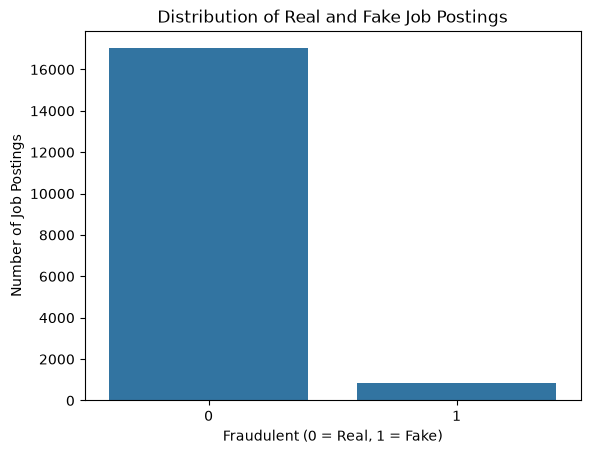

In [76]:
sns.countplot(data=df, x="fraudulent")

plt.title("Distribution of Real and Fake Job Postings")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Number of Job Postings")
plt.show()

In [77]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
title                      0
fraudulent                 0
dtype: int64

In [78]:
missing[missing > 0]

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
dtype: int64

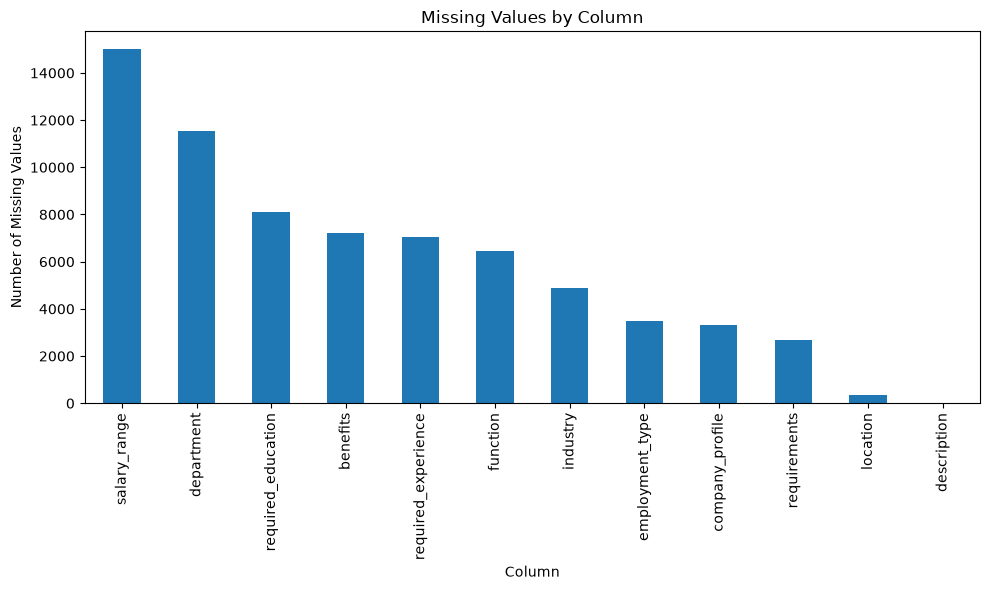

In [79]:
plt.figure(figsize=(10, 6))

missing[missing > 0].plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [80]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

df[text_columns].head()

,title,company_profile,description,requirements,benefits
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered


In [81]:
for column in text_columns:
    print(column, ":", df[column].notna().sum(), "non-missing values")

title : 17880 non-missing values
company_profile : 14572 non-missing values
description : 17879 non-missing values
requirements : 15184 non-missing values
benefits : 10668 non-missing values


In [82]:
df[text_columns].isnull().sum()

title                 0
company_profile    3308
description           1
requirements       2696
benefits           7212
dtype: int64

In [83]:
df_clean = df.copy()

In [84]:
print("Duplicates before:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicates after:", df_clean.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [85]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    df_clean[column] = df_clean[column].fillna("")

In [86]:
df_clean[text_columns].isnull().sum()

title              0
company_profile    0
description        0
requirements       0
benefits           0
dtype: int64

In [87]:
df_clean["full_text"] = (
    df_clean["title"] + " " +
    df_clean["company_profile"] + " " +
    df_clean["description"] + " " +
    df_clean["requirements"] + " " +
    df_clean["benefits"]
)

In [88]:
df_clean[["title", "full_text"]].head(3)

,title,full_text
0,Marketing Intern,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) Valor ...


In [89]:
df_clean["word_count"] = df_clean["full_text"].str.split().str.len()

df_clean["word_count"].describe()

count    17880.000000
mean       374.771868
std        207.598093
min          2.000000
25%        229.000000
50%        349.000000
75%        492.000000
max       2118.000000
Name: word_count, dtype: float64

In [90]:
df_clean.groupby("fraudulent")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,379.478488,206.694606,7.0,235.0,355.0,496.00,2118.0
1,866.0,282.302540,203.746359,2.0,133.0,224.5,384.25,1338.0


In [91]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [92]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/divyanshchawlaa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/divyanshchawlaa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/divyanshchawlaa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [93]:
def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [94]:
example = df_clean["full_text"].iloc[0]

print("ORIGINAL:")
print(example[:500])

print("\nCLEANED:")
print(basic_clean(example)[:500])

ORIGINAL:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributor

CLEANED:
marketing intern we re food and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better ways to connect people around their specific food interests and to offer them superb highly curated information about food and cooking we attract the most talented home cooks and con

In [95]:
import nltk
import os

nltk_data_path = os.path.join(os.getcwd(), "nltk_data")

os.makedirs(nltk_data_path, exist_ok=True)

nltk.data.path.append(nltk_data_path)

nltk.download("stopwords", download_dir=nltk_data_path)

print("NLTK data location:", nltk_data_path)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/divyanshchawlaa/Documents/Gisma/Ai
[nltk_data]     Applications/fake-job-posting-
[nltk_data]     detection/notebooks/nltk_data...


NLTK data location: /Users/divyanshchawlaa/Documents/Gisma/Ai Applications/fake-job-posting-detection/notebooks/nltk_data


[nltk_data]   Unzipping corpora/stopwords.zip.


In [96]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


In [97]:
def clean_with_stopwords(text):
    text = basic_clean(text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [98]:
lemmatizer = WordNetLemmatizer()

def clean_with_lemmatization(text):
    text = basic_clean(text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)


In [99]:
example = df_clean["full_text"].iloc[0]

print("BASIC:")
print(basic_clean(example)[:300])

print("\nSTOPWORDS REMOVED:")
print(clean_with_stopwords(example)[:300])

print("\nLEMMATIZED:")
print(clean_with_lemmatization(example)[:300])

BASIC:
marketing intern we re food and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better way

STOPWORDS REMOVED:
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cooks give everything need one place top editorial business engineering team focused using technology find new better ways connect people around specific food interests offer superb highly curated 

LEMMATIZED:
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top editorial business engineering team focused using technology find new better way connect people around specific food interest offer superb highly curated inf


In [100]:
df_clean["text_basic"] = df_clean["full_text"].apply(basic_clean)

df_clean["text_stopwords"] = df_clean["full_text"].apply(
    clean_with_stopwords
)

df_clean["text_lemmatized"] = df_clean["full_text"].apply(
    clean_with_lemmatization
)

print("All three preprocessing columns created successfully!")

All three preprocessing columns created successfully!


In [101]:
print(df_clean[[
    "text_basic",
    "text_stopwords",
    "text_lemmatized"
]].head())

                                          text_basic  \
0  marketing intern we re food and we ve created ...   
1  customer service cloud video production second...   
2  commissioning machinery assistant cma valor se...   
3  account executive washington dc our passion fo...   
4  bill review manager spotsource solutions llc i...   

                                      text_stopwords  \
0  marketing intern food created groundbreaking a...   
1  customer service cloud video production second...   
2  commissioning machinery assistant cma valor se...   
3  account executive washington dc passion improv...   
4  bill review manager spotsource solutions llc g...   

                                     text_lemmatized  
0  marketing intern food created groundbreaking a...  
1  customer service cloud video production second...  
2  commissioning machinery assistant cma valor se...  
3  account executive washington dc passion improv...  
4  bill review manager spotsource solution llc gl..

In [102]:
df_clean["basic_words"] = df_clean["text_basic"].str.split().str.len()
df_clean["stopword_words"] = df_clean["text_stopwords"].str.split().str.len()
df_clean["lemmatized_words"] = df_clean["text_lemmatized"].str.split().str.len()

print(df_clean[[
    "basic_words",
    "stopword_words",
    "lemmatized_words"
]].describe())

        basic_words  stopword_words  lemmatized_words
count  17880.000000    17880.000000      17880.000000
mean     398.302013      253.822092        253.822092
std      219.077023      136.294975        136.294975
min        2.000000        2.000000          2.000000
25%      243.000000      151.000000        151.000000
50%      370.000000      239.000000        239.000000
75%      521.000000      330.000000        330.000000
max     2161.000000     1423.000000       1423.000000


In [103]:
df_clean.to_csv("../data/fake_job_postings_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully!
Shape: (17880, 26)


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [105]:
X = df_clean["text_lemmatized"]
y = df_clean["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 14304
Testing samples: 3576

Training class distribution:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Testing class distribution:
fraudulent
0    3403
1     173
Name: count, dtype: int64


In [106]:
print("Training fake percentage:",
      round(y_train.mean() * 100, 2), "%")

print("Testing fake percentage:",
      round(y_test.mean() * 100, 2), "%")

Training fake percentage: 4.84 %
Testing fake percentage: 4.84 %


In [107]:
count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("CountVectorizer training shape:", X_train_count.shape)
print("CountVectorizer testing shape:", X_test_count.shape)

CountVectorizer training shape: (14304, 366094)
CountVectorizer testing shape: (3576, 366094)


In [108]:
print("Number of CountVectorizer features:",
      len(count_vectorizer.get_feature_names_out()))

print("\nFirst 20 features:")
print(count_vectorizer.get_feature_names_out()[:20])

Number of CountVectorizer features: 366094

First 20 features:
['aa' 'aa aa' 'aa ab' 'aa acbd' 'aa ad' 'aa ada' 'aa adbc' 'aa adf'
 'aa ae' 'aa aefcbccb' 'aa af' 'aa apply' 'aa ba' 'aa bb' 'aa bc' 'aa bcc'
 'aa bcd' 'aa bd' 'aa bf' 'aa bfa']


In [109]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (14304, 366094)
TF-IDF testing shape: (3576, 366094)


In [110]:
print("CountVectorizer:")
print("Training:", X_train_count.shape)
print("Testing :", X_test_count.shape)

print("\nTF-IDF:")
print("Training:", X_train_tfidf.shape)
print("Testing :", X_test_tfidf.shape)

CountVectorizer:
Training: (14304, 366094)
Testing : (3576, 366094)

TF-IDF:
Training: (14304, 366094)
Testing : (3576, 366094)


In [111]:
import joblib

joblib.dump(count_vectorizer, "../models/count_vectorizer.joblib")
joblib.dump(tfidf_vectorizer, "../models/tfidf_vectorizer.joblib")

print("Vectorizers saved successfully!")

Vectorizers saved successfully!


In [112]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [113]:
nb_count = MultinomialNB()

nb_count.fit(X_train_count, y_train)

nb_count_pred = nb_count.predict(X_test_count)

print("Naive Bayes - CountVectorizer")
print("Accuracy :", accuracy_score(y_test, nb_count_pred))
print("Precision:", precision_score(y_test, nb_count_pred))
print("Recall   :", recall_score(y_test, nb_count_pred))
print("F1 Score :", f1_score(y_test, nb_count_pred))

Naive Bayes - CountVectorizer
Accuracy : 0.9848993288590604
Precision: 0.9612403100775194
Recall   : 0.7167630057803468
F1 Score : 0.8211920529801324


In [114]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

nb_tfidf_pred = nb_tfidf.predict(X_test_tfidf)

print("Naive Bayes - TF-IDF")
print("Accuracy :", accuracy_score(y_test, nb_tfidf_pred))
print("Precision:", precision_score(y_test, nb_tfidf_pred))
print("Recall   :", recall_score(y_test, nb_tfidf_pred))
print("F1 Score :", f1_score(y_test, nb_tfidf_pred))

Naive Bayes - TF-IDF
Accuracy : 0.9586129753914989
Precision: 1.0
Recall   : 0.14450867052023122
F1 Score : 0.25252525252525254


In [115]:
lr_count = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_count.fit(X_train_count, y_train)

lr_count_pred = lr_count.predict(X_test_count)

print("Logistic Regression - CountVectorizer")
print("Accuracy :", accuracy_score(y_test, lr_count_pred))
print("Precision:", precision_score(y_test, lr_count_pred))
print("Recall   :", recall_score(y_test, lr_count_pred))
print("F1 Score :", f1_score(y_test, lr_count_pred))

Logistic Regression - CountVectorizer
Accuracy : 0.9865771812080537
Precision: 0.8834355828220859
Recall   : 0.8323699421965318
F1 Score : 0.8571428571428571


In [116]:
lr_tfidf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_tfidf.fit(X_train_tfidf, y_train)

lr_tfidf_pred = lr_tfidf.predict(X_test_tfidf)

print("Logistic Regression - TF-IDF")
print("Accuracy :", accuracy_score(y_test, lr_tfidf_pred))
print("Precision:", precision_score(y_test, lr_tfidf_pred))
print("Recall   :", recall_score(y_test, lr_tfidf_pred))
print("F1 Score :", f1_score(y_test, lr_tfidf_pred))

Logistic Regression - TF-IDF
Accuracy : 0.9902125279642058
Precision: 0.9058823529411765
Recall   : 0.8901734104046243
F1 Score : 0.8979591836734694


In [118]:
svm_count = LinearSVC(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

svm_count.fit(X_train_count, y_train)

svm_count_pred = svm_count.predict(X_test_count)

print("Linear SVM - CountVectorizer")
print("Accuracy :", accuracy_score(y_test, svm_count_pred))
print("Precision:", precision_score(y_test, svm_count_pred))
print("Recall   :", recall_score(y_test, svm_count_pred))
print("F1 Score :", f1_score(y_test, svm_count_pred))

Linear SVM - CountVectorizer
Accuracy : 0.982662192393736
Precision: 0.84472049689441
Recall   : 0.7861271676300579
F1 Score : 0.8143712574850299


/Users/divyanshchawlaa/Documents/Gisma/Ai Applications/fake-job-posting-detection/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [119]:
svm_tfidf = LinearSVC(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

svm_tfidf.fit(X_train_tfidf, y_train)

svm_tfidf_pred = svm_tfidf.predict(X_test_tfidf)

print("Linear SVM - TF-IDF")
print("Accuracy :", accuracy_score(y_test, svm_tfidf_pred))
print("Precision:", precision_score(y_test, svm_tfidf_pred))
print("Recall   :", recall_score(y_test, svm_tfidf_pred))
print("F1 Score :", f1_score(y_test, svm_tfidf_pred))

Linear SVM - TF-IDF
Accuracy : 0.9918903803131991
Precision: 0.9864864864864865
Recall   : 0.8439306358381503
F1 Score : 0.9096573208722741


In [120]:
print("Best Logistic Regression F1:", f1_score(y_test, lr_tfidf_pred))
print("Best Linear SVM F1:", f1_score(y_test, svm_tfidf_pred))

Best Logistic Regression F1: 0.8979591836734694
Best Linear SVM F1: 0.9096573208722741


In [121]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Naive Bayes",
        "Logistic Regression",
        "Logistic Regression",
        "Linear SVM",
        "Linear SVM"
    ],
    "Features": [
        "CountVectorizer",
        "TF-IDF",
        "CountVectorizer",
        "TF-IDF",
        "CountVectorizer",
        "TF-IDF"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_count_pred),
        accuracy_score(y_test, nb_tfidf_pred),
        accuracy_score(y_test, lr_count_pred),
        accuracy_score(y_test, lr_tfidf_pred),
        accuracy_score(y_test, svm_count_pred),
        accuracy_score(y_test, svm_tfidf_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_count_pred),
        precision_score(y_test, nb_tfidf_pred),
        precision_score(y_test, lr_count_pred),
        precision_score(y_test, lr_tfidf_pred),
        precision_score(y_test, svm_count_pred),
        precision_score(y_test, svm_tfidf_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_count_pred),
        recall_score(y_test, nb_tfidf_pred),
        recall_score(y_test, lr_count_pred),
        recall_score(y_test, lr_tfidf_pred),
        recall_score(y_test, svm_count_pred),
        recall_score(y_test, svm_tfidf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_count_pred),
        f1_score(y_test, nb_tfidf_pred),
        f1_score(y_test, lr_count_pred),
        f1_score(y_test, lr_tfidf_pred),
        f1_score(y_test, svm_count_pred),
        f1_score(y_test, svm_tfidf_pred)
    ]
})

results = results.round(4)

results

,Model,Features,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,CountVectorizer,0.9849,0.9612,0.7168,0.8212
1,Naive Bayes,TF-IDF,0.9586,1.0000,0.1445,0.2525
2,Logistic Regression,CountVectorizer,0.9866,0.8834,0.8324,0.8571
3,Logistic Regression,TF-IDF,0.9902,0.9059,0.8902,0.8980
4,Linear SVM,CountVectorizer,0.9827,0.8447,0.7861,0.8144
5,Linear SVM,TF-IDF,0.9919,0.9865,0.8439,0.9097


In [122]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [123]:
cm_lr = confusion_matrix(y_test, lr_tfidf_pred)

print("Logistic Regression + TF-IDF")
print(cm_lr)

Logistic Regression + TF-IDF
[[3387   16]
 [  19  154]]


In [124]:
cm_svm = confusion_matrix(y_test, svm_tfidf_pred)

print("Linear SVM + TF-IDF")
print(cm_svm)

Linear SVM + TF-IDF
[[3401    2]
 [  27  146]]


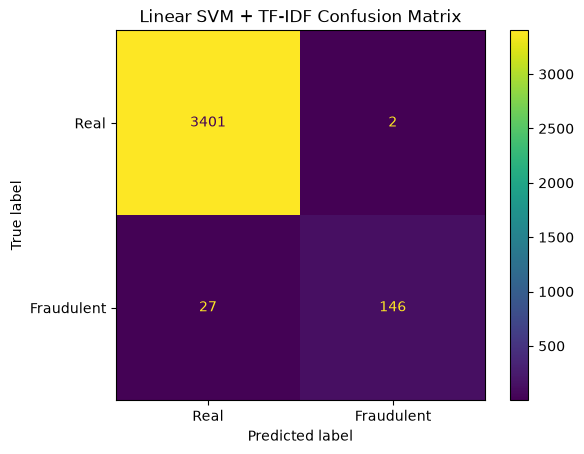

In [125]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Real", "Fraudulent"]
)

disp.plot()
plt.title("Linear SVM + TF-IDF Confusion Matrix")
plt.show()

In [126]:
plt.savefig("../models/svm_tfidf_confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [127]:
lr_scores = lr_tfidf.decision_function(X_test_tfidf)
svm_scores = svm_tfidf.decision_function(X_test_tfidf)

lr_auc = roc_auc_score(y_test, lr_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

print("Logistic Regression + TF-IDF ROC-AUC:", round(lr_auc, 4))
print("Linear SVM + TF-IDF ROC-AUC:", round(svm_auc, 4))

Logistic Regression + TF-IDF ROC-AUC: 0.9886
Linear SVM + TF-IDF ROC-AUC: 0.9942


In [128]:
import joblib

# Save the final TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, "../models/tfidf_vectorizer.joblib")

# Save the final Linear SVM model
joblib.dump(svm_tfidf, "../models/svm_tfidf_model.joblib")

print("Final model and vectorizer saved successfully.")

Final model and vectorizer saved successfully.


In [129]:
# Load the saved files
loaded_vectorizer = joblib.load("../models/tfidf_vectorizer.joblib")
loaded_model = joblib.load("../models/svm_tfidf_model.joblib")

print("Vectorizer loaded:", type(loaded_vectorizer).__name__)
print("Model loaded:", type(loaded_model).__name__)

Vectorizer loaded: TfidfVectorizer
Model loaded: LinearSVC


In [130]:
# Test the saved model on actual examples from the dataset

import joblib

loaded_vectorizer = joblib.load("../models/tfidf_vectorizer.joblib")
loaded_model = joblib.load("../models/svm_tfidf_model.joblib")

# Find one real and one fraudulent posting
real_example = df_clean[df_clean["fraudulent"] == 0].iloc[0]
fake_example = df_clean[df_clean["fraudulent"] == 1].iloc[0]

# Preprocess using the exact same function used during training
real_text = real_example["text_lemmatized"]
fake_text = fake_example["text_lemmatized"]

# Transform
real_features = loaded_vectorizer.transform([real_text])
fake_features = loaded_vectorizer.transform([fake_text])

# Predict
real_prediction = loaded_model.predict(real_features)[0]
fake_prediction = loaded_model.predict(fake_features)[0]

print("REAL EXAMPLE")
print("Actual label:", real_example["fraudulent"])
print("Predicted label:", real_prediction)

print("\nFRAUDULENT EXAMPLE")
print("Actual label:", fake_example["fraudulent"])
print("Predicted label:", fake_prediction)

REAL EXAMPLE
Actual label: 0
Predicted label: 0

FRAUDULENT EXAMPLE
Actual label: 1
Predicted label: 1


In [131]:
print(fake_example["full_text"])


IC&E Technician                                                                                  Staffing &amp; Recruiting done right for the Oil &amp; Energy Industry!Represented candidates are automatically granted the following perks: Expert negotiations on your behalf, maximizing your compensation package and implimenting ongoing increases Significant signing bonus by Refined Resources (in addition to any potential signing bonuses our client companies offer)1 Year access to AnyPerk: significant corporate discounts on cell phones, event tickets, house cleaning and everything inbetween.  You'll save thousands on daily expenditures Professional Relocation Services for out of town candidates* All candidates are encouraged to participate in our Referral Bonus Program ranging anywhere from $500 - $1,000 for all successfully hired candidates... referred directly to the Refined Resources teamPlease submit referrals via online Referral FormThank you and we look forward to working with you s